# HGG Example

In this notebook, we will aim to estimate the (spatially varying) proliferation rate of the tumor of a particular patient.

In [6]:
from datetime import timedelta
import math
import pathlib
import time

from matplotlib import pyplot as plt
from pydantic import FilePath
from rich import print
import torch
import torch.multiprocessing as mp

from tumortwin.models.reaction_diffusion_3d_nn import ReactionDiffusion3D
from tumortwin.postprocessing import (
    compute_total_cell_count,
    plot_calibration,
    plot_calibration_iter,
    plot_cellularity_map,
    plot_imaging_summary,
    plot_loss,
    plot_measured_TCC,
    plot_patient_timeline,
    plot_predicted_TCC,
)
from tumortwin.preprocessing import ADC_to_cellularity, compute_carrying_capacity
from tumortwin.solvers import TorchDiffEqSolver, TorchDiffEqSolverOptions
from tumortwin.types import (
    ChemotherapySpecification,
    CropSettings,
    CropTarget,
    RadiotherapySpecification,
)
from tumortwin.types.hgg_data import HGGPatientData
from tumortwin.utils import daterange, days_since_first

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}.")

Using device: cpu.

## Data

We start by reading in the data.

In [8]:
# type: ignore
DATA_FOLDER = pathlib.Path("input_files")
PATIENT_INFO_PATH = FilePath(f"{DATA_FOLDER}/HGG_demo_001/HGG_demo_001.json")
IMAGE_PATH = FilePath(f"{DATA_FOLDER}/HGG_demo_001")

In [9]:
crop_settings = CropSettings(
    crop_to=CropTarget.ROI_ENHANCE, 
    padding=10, 
    visit_index=-1
)

patient_data = HGGPatientData.from_file(
    PATIENT_INFO_PATH, 
    image_dir=IMAGE_PATH, 
    crop_settings=crop_settings
)

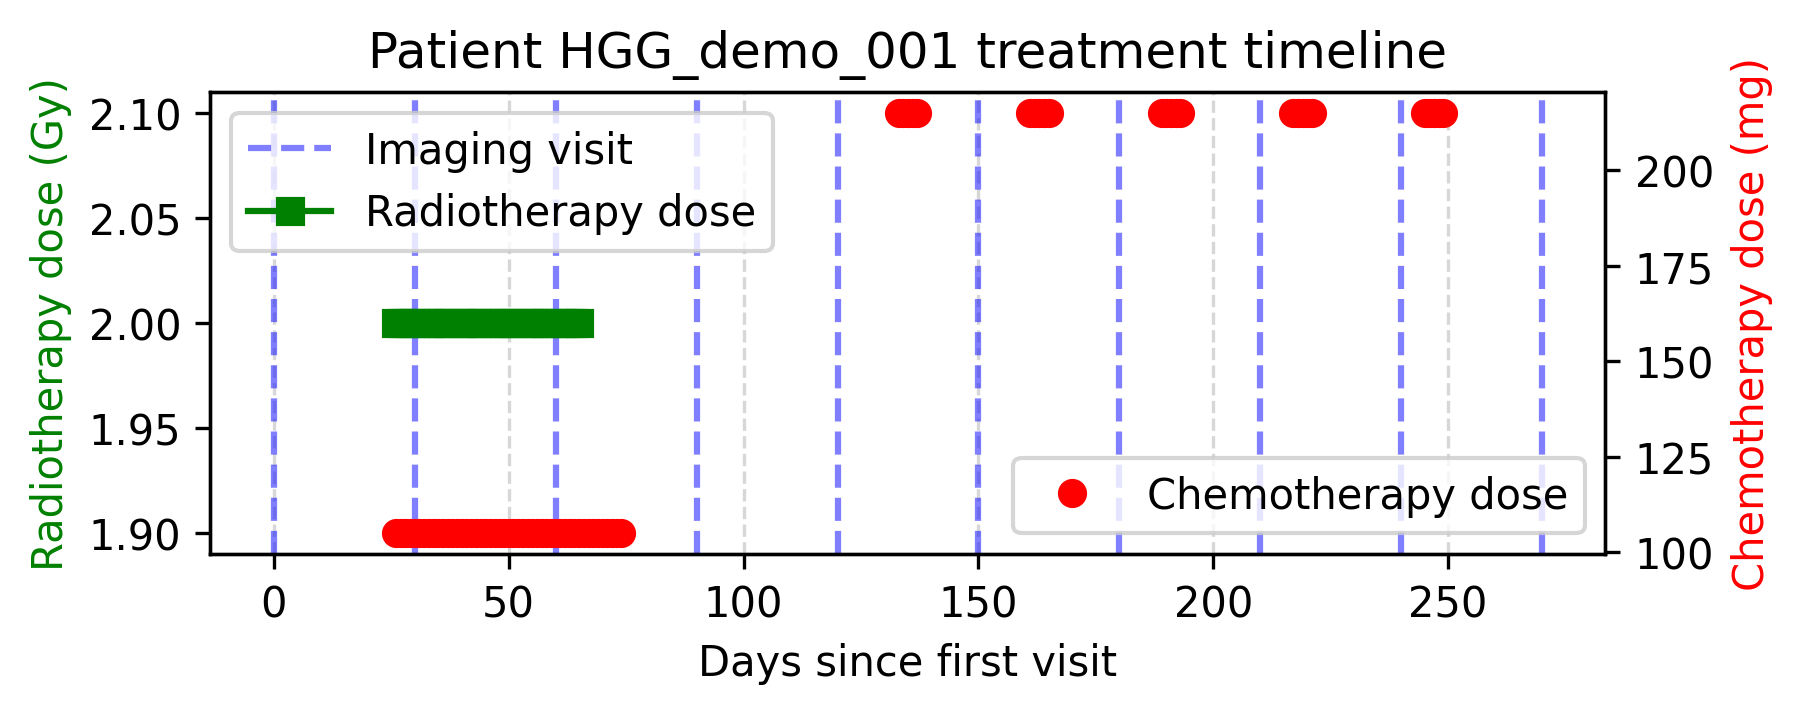

In [10]:
plot_patient_timeline(patient_data)

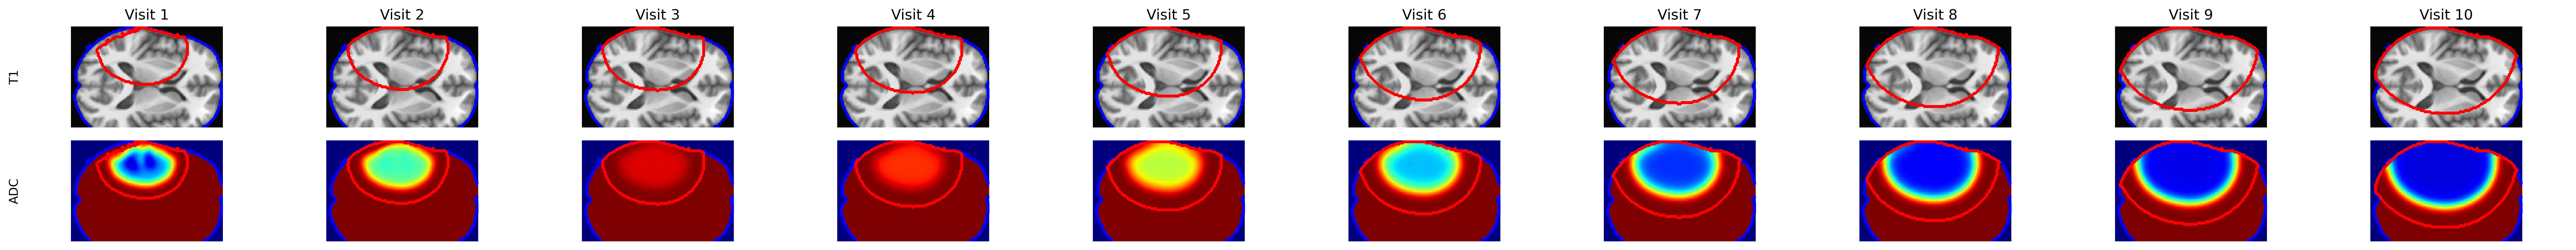

In [11]:
plot_imaging_summary(patient_data)

In [12]:
measured_cellularity_maps = [
    ADC_to_cellularity(
        visit.adc_image, visit.roi_enhance_image, visit.roi_nonenhance_image
    )
    for visit in patient_data.visits
]

In [13]:
# Model Parameters: k = proliferation rate, d = diffusivity, theta = carrying capacity
k = torch.tensor(0.05, requires_grad=True, device=device)
d = torch.tensor(0.025, requires_grad=True, device=device)
theta = torch.tensor(1.0, requires_grad=False, device=device)

In [14]:
rt = RadiotherapySpecification(
    alpha=0.025,
    alpha_beta_ratio=10,
    times=[r.time for r in patient_data.radiotherapy],
    doses=[r.dose for r in patient_data.radiotherapy],
)

ct = ChemotherapySpecification(
    sensitivity=0.5,
    decay_rate=9.2420,
    times=[c.time for c in patient_data.chemotherapy],
    doses=[c.dose for c in patient_data.chemotherapy],
)

In [15]:
# How many imaging dates do we want to try and match
n_visits_calibration = 5  # *Including* the initial visit

target_timepoints = [visit.time for visit in patient_data.visits[:n_visits_calibration]]
target_solution = torch.stack(
    tuple(
        [
            torch.from_numpy(m.array)
            for m in measured_cellularity_maps[: n_visits_calibration]
        ]
    )
)

In [16]:

timepoints = daterange(
    patient_data.visits[0].time, patient_data.visits[-1].time, timedelta(days=0.5)
)
# Initial condition for solver
u0 = torch.from_numpy(measured_cellularity_maps[0].array)

## Model and Solver

We now define the model, and the solver that will be used.

In [17]:
model = ReactionDiffusion3D(
    k=k,
    d=d,
    theta=theta,
    patient_data=patient_data,
    initial_time=patient_data.visits[0].time,
    chemotherapy_specifications=[ct],
    radiotherapy_specification=rt,
)

solver_options = TorchDiffEqSolverOptions(
    step_size=timedelta(days=0.5),
    use_adjoint=True,
    device=device,
    method="rk4",
)

solver = TorchDiffEqSolver(model, solver_options)

In [ ]:
# type: ignore

def update_model_and_predict(model_parameters, timepoints=target_timepoints):
    
    d, k, alpha, ct_sens = torch.nn.Parameter(model_parameters)
    solver.model.d = torch.nn.Parameter(d)
    solver.model.k = torch.nn.Parameter(k)
    solver.model.radiotherapy_specification.alpha = torch.nn.Parameter(alpha) 
    solver.model.chemotherapy_specifications[0].sensitivity = torch.nn.Parameter(ct_sens)

    _, predicted_cellularity_maps = solver.solve(timepoints=timepoints, u_initial=u0)
    return predicted_cellularity_maps

In [ ]:
# type: ignore

from torch import Tensor
import time

def negloglik(params: Tensor) -> Tensor:
    """Evaluates the negative log-likelihood function at each """

    neglogliks = torch.zeros((params.shape[0],))

    for i, params_i in enumerate(params):

        t0 = time.time()

        d, k, alpha, ct_sens = params_i

        solver.model.d = torch.nn.Parameter(d)
        solver.model.k = torch.nn.Parameter(k)
        solver.model.radiotherapy_specification.alpha = torch.nn.Parameter(alpha)
        solver.model.chemotherapy_specifications[0].sensitivity = torch.nn.Parameter(ct_sens)

        predicted_cellularity_maps = solver.solve(target_timepoints, u0)[1]
        # print(predicted_cellularity_maps)
        # print(target_solution)
        # print(predicted_cellularity_maps.shape)
        # print(target_solution.shape)
        nll = (1.0 / (2.0 * sd_noise ** 2)) * (predicted_cellularity_maps - target_solution).square().sum()
        print(nll)
        neglogliks[i] = nll

        t1 = time.time()
        print(f"Finished in {t1-t0:.4f} s.")
    
    return neglogliks

In [ ]:
# def negloglik(args):

#     params, i, neglogliks, target_solution, solver, u0, timepoints = args

#     print(f"Simulation {i}")
    
#     d, k, alpha, ct_sens = torch.nn.Parameter(params)
#     solver.model.d = torch.nn.Parameter(d)
#     solver.model.k = torch.nn.Parameter(k)
#     solver.model.radiotherapy_specification.alpha = torch.nn.Parameter(alpha)
#     solver.model.chemotherapy_specifications[0].sensitivity = torch.nn.Parameter(ct_sens)

#     _, predicted_cellularity_maps = solver.solve(timepoints, u0)
#     nll = 0.5 * (predicted_cellularity_maps - target_solution).square().sum()
#     neglogliks[i] = nll.detach()
#     return neglogliks[i]

In [38]:
print(target_solution.max())

tensor(1., dtype=torch.float64)

In [ ]:
bounds = torch.tensor([[0.0, 2.0], [0.0, 0.5], [0.001, 0.1], [0.0, 1.0]])
dxs = bounds[:, 1] - bounds[:, 0]

num_samples = 3
dim = 4
xs = torch.rand((num_samples, dim)) * dxs + bounds[:, 0]

In [39]:
negloglik(xs)

Forward Simulation: [1996-11-15 00:00:00 to 1997-03-15 00:00:00 with timestep 0.50 days]:   0%|          | 0.0…

tensor(500689.9875, dtype=torch.float64, grad_fn=<MulBackward0>)

Finished in 11.3867 s.

Forward Simulation: [1996-11-15 00:00:00 to 1997-03-15 00:00:00 with timestep 0.50 days]:   0%|          | 0.0…

tensor(217402.0509, dtype=torch.float64, grad_fn=<MulBackward0>)

...

Forward Simulation: [1996-11-15 00:00:00 to 1997-03-15 00:00:00 with timestep 0.50 days]:   0%|          | 0.0…

tensor(329933.5924, dtype=torch.float64, grad_fn=<MulBackward0>)

Finished in 15.2178 s.

Forward Simulation: [1996-11-15 00:00:00 to 1997-03-15 00:00:00 with timestep 0.50 days]:   0%|          | 0.0…

KeyboardInterrupt: 